<a href="https://colab.research.google.com/github/rsher60/LLM_Codebase/blob/main/fine_tuning_patent_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install necessary packages to finetune datasets with SFT

In [ ]:
#!pip install -U transformers accelerate datasets bertviz umap-learn seaborn openpyxl --upgrade

In [1]:
import os
os.environ['TORCH_USE_CUDA_DSA'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

Login to HuggingFace. I have stored my creds in colab secrets

In [3]:
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

splits = {'train': 'patent/train-00000-of-00001.parquet', 'validation': 'patent/validation-00000-of-00001.parquet', 'test': 'patent/test-00000-of-00001.parquet'}
df = pd.read_parquet("hf://datasets/ccdv/patent-classification/" + splits["train"])

In [5]:
df.dtypes

,0
text,object
label,int64


In [6]:
df = df.rename(columns={'label': 'labels'})

In [7]:
#Bin the categories

freq_df = df.groupby('labels').size().reset_index(name='count')

freq_df
#min(freq_df['count']) , max(freq_df['count'])



,labels,count
0,0,3614
1,1,3357
2,2,2099
3,3,204
4,4,705
5,5,1730
6,6,5408
7,7,5321
8,8,2562


# Plot the frequency of classes

In [8]:
import matplotlib.pyplot as plt


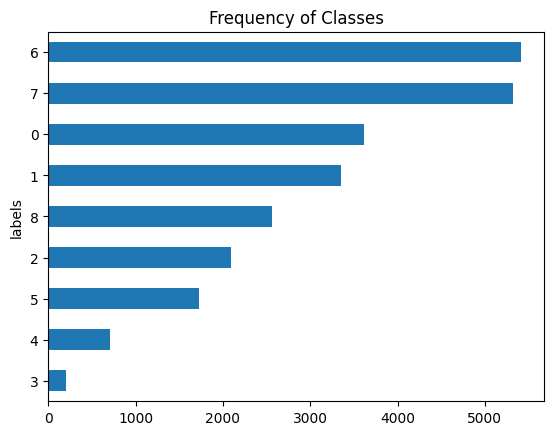

In [9]:
label_counts = df['labels'].value_counts(ascending=True)
label_counts.plot.barh()
plt.title('Frequency of Classes')
plt.show()

Data Loader and Splitting the Data

In [10]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3,stratify=df['labels']) #can play around with the size of the test datset

test, validation = train_test_split(test, test_size=1/3, stratify=test['labels'])


In [32]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(train, preserve_index=False),
        "test": Dataset.from_pandas(test, preserve_index=False),
        "validation": Dataset.from_pandas(validation, preserve_index=False),
    }
)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 17500
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5000
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 2500
    })
})

# Data Tokenization

In [33]:
from transformers import AutoTokenizer

text = "Riddhiman Sherlekar is an expert in AI"

model_checkpoint = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
distilbert_tokens = distilbert_tokenizer.tokenize(text)

In [34]:
def tokenize(batch):
  temp = distilbert_tokenizer(batch['text'], padding=True, truncation=True)
  return temp


print(tokenize(dataset['train'][:3]))

{'input_ids': [[101, 1999, 20965, 2487, 1037, 1998, 26314, 1010, 1037, 3252, 1997, 2019, 2061, 2072, 1011, 2828, 20681, 5080, 2429, 2000, 1037, 3937, 7861, 5092, 21341, 1997, 1996, 2556, 11028, 2003, 3491, 1012, 20965, 2487, 1037, 3065, 1037, 8040, 28433, 4588, 27197, 3193, 1997, 1037, 2112, 1997, 2019, 2061, 2072, 1011, 2828, 20681, 5080, 1998, 20965, 2487, 1038, 3065, 1037, 7704, 4984, 16403, 1999, 2112, 1997, 1996, 2061, 2072, 1011, 2828, 20681, 5080, 1012, 1999, 20965, 2487, 1037, 1010, 2659, 9507, 7730, 20681, 4655, 23409, 1998, 1016, 2497, 2024, 2719, 2306, 2019, 16021, 10924, 2555, 1015, 2006, 1037, 3302, 1997, 1037, 2490, 20681, 16305, 1017, 1997, 1996, 2061, 2072, 1011, 2828, 20681, 5080, 1012, 1037, 1058, 7020, 2240, 1019, 1998, 1037, 1058, 20315, 2240, 1020, 2024, 4198, 2000, 1996, 2659, 9507, 7730, 20681, 4655, 23409, 1998, 1016, 2497, 1010, 4414, 1012, 2182, 1010, 1996, 2659, 9507, 7730, 20681, 4655, 23409, 1998, 1016, 2497, 2003, 20271, 7275, 2011, 1037, 3280, 2571, 22601

In [35]:
encoded_dataset = dataset.map(
    tokenize,
    batched=True,
    batch_size=1000,  # <--- IMPORTANT: Set a specific batch size here
    num_proc=4, # <--- Optional: Uncomment and set if you want parallel processing
    remove_columns=['text'] # Optional: Remove the original text column to save memory
)

Map (num_proc=4):   0%|          | 0/17500 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/5000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2500 [00:00<?, ? examples/s]

# Model Building

In [36]:
from transformers import AutoModelForSequenceClassification, AutoConfig

import torch

label2id  = {'Physics': 6, 'Human Necessities': 0, 'Electricity': 7, 'Performing Operations': 1, 'General tagging': 8, 'Chemistry': 2, 'Fixed Constructions': 4, 'Textiles': 3 , 'Mechanical Engineering':5}

id2label  =  {6: 'Physics', 0: 'Human Necessities', 7: 'Electricity', 1: 'Performing Operations', 8: 'General tagging', 2: 'Chemistry', 4: 'Fixed Constructions', 3: 'Textiles', 5:'Mechanical Engineering'}

In [37]:
len(label2id)
len(id2label)

9

In [38]:
model_checkpoint = "distilbert-base-uncased"

num_labels = len(label2id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = AutoConfig.from_pretrained(model_checkpoint, label2id=label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint,config=config).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
device

device(type='cuda')

# Model Fine Tuning

The first thing we need is a pretrained BERT like model
THe only slight modification is that we use the AutoModelForSequenceClassification model instead of AutoModel

The difference is that the AutoModelForSequenceClassification model has a classification head on top of pretrained model outputs, which can be easily trained with the base model.

Evaluate

In [26]:
#!pip install evaluate

In [40]:
import evaluate
import numpy as np


accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)
  return accuracy.compute(predictions=predictions, references=labels)

  accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred

    # --- DEBUGGING STEP 1: Check raw predictions ---
    print(f"Predictions type: {type(predictions)}, shape: {predictions.shape}")
    # Convert predictions to a PyTorch tensor temporarily to use .isnan()/.isinf()
    # If predictions are already numpy, convert to tensor:
    if isinstance(predictions, np.ndarray):
        predictions_tensor = torch.from_numpy(predictions)
    else: # Assume it's already a tensor if not numpy
        predictions_tensor = predictions

    if torch.isnan(predictions_tensor).any():
        print("\n!!! NaN detected in raw predictions !!!")
        print("Raw Predictions (first 5 rows):\n", predictions[:5])
        # Optionally, save predictions to a file for later inspection
        # np.save('nan_predictions.npy', predictions)
        raise ValueError("NaNs found in model predictions during evaluation!")

    if torch.isinf(predictions_tensor).any():
        print("\n!!! Inf detected in raw predictions !!!")
        print("Raw Predictions (first 5 rows):\n", predictions[:5])
        raise ValueError("Infs found in model predictions during evaluation!")

    # --- DEBUGGING STEP 2: Check labels ---
    print(f"Labels type: {type(labels)}, shape: {labels.shape}")
    if isinstance(labels, np.ndarray):
        labels_tensor = torch.from_numpy(labels)
    else:
        labels_tensor = labels

    if torch.isnan(labels_tensor).any():
        print("\n!!! NaN detected in labels !!!")
        raise ValueError("NaNs found in labels during evaluation!")
    if torch.isinf(labels_tensor).any():
        print("\n!!! Inf detected in labels !!!")
        raise ValueError("Infs found in labels during evaluation!")


    # Proceed with your logic if predictions and labels are clean
    predictions = np.argmax(predictions, axis=1)

    # --- DEBUGGING STEP 3: Check argmax output ---
    if np.isnan(predictions).any():
        print("\n!!! NaN detected after np.argmax in predictions !!!")
        raise ValueError("NaNs found after argmax!")
    if np.isinf(predictions).any():
        print("\n!!! Inf detected after np.argmax in predictions !!!")
        raise ValueError("Infs found after argmax!")

    # Ensure predictions and references have compatible types and values for the metric
    print(f"Predictions after argmax (first 10): {predictions[:10]}")
    print(f"Labels (first 10): {labels[:10]}")


    return accuracy.compute(predictions=predictions, references=labels)



In [41]:
from transformers import TrainingArguments

#In the latest transformer version evaluation_strategy was replaced by eval_strategy

batch_size = 32
training_dir = "train_dir"

training_args = TrainingArguments(
    output_dir = training_dir,
    overwrite_output_dir = True,
    num_train_epochs = 2,
    learning_rate = 2e-5,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    weight_decay = 0.01,
    # Corrected argument name
    eval_strategy = 'epoch',
    # It's also common to set save_strategy to match eval_strategy
    save_strategy = 'epoch',
    max_grad_norm=1.0,
    # Optionally, specify how often to save checkpoints based on the strategy
    save_steps = 500 # This would save every 500 steps if save_strategy was 'steps'
                     # For 'epoch', it typically saves at the end of each epoch by default.
                     # You can omit save_steps if you just want to save per epoch
)

In [42]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [43]:
from transformers import Trainer

trainer = Trainer(
    model = model,
    compute_metrics = compute_metrics_evaluate,
    train_dataset = encoded_dataset['train'],
    eval_dataset= encoded_dataset['validation'],
    tokenizer=distilbert_tokenizer,

)

In [44]:
import torch
torch.autograd.set_detect_anomaly(True)

# ... your trainer setup ...
trainer.train()

Step,Training Loss
500,1.441400
1000,1.226700
1500,1.151000
2000,1.089100
2500,0.987300
3000,0.902500
3500,0.906300
4000,0.885700
4500,0.826000
5000,0.671800


TrainOutput(global_step=6564, training_loss=0.9166004208803613, metrics={'train_runtime': 2934.6908, 'train_samples_per_second': 17.889, 'train_steps_per_second': 2.237, 'total_flos': 6955406599680000.0, 'train_loss': 0.9166004208803613, 'epoch': 3.0})

SAve the model

In [45]:
trainer.save_model("rsher60/patent_classification")

# Model Evaluation

In [46]:
preds_output = trainer.predict(encoded_dataset['test'])

Predictions type: <class 'numpy.ndarray'>, shape: (5000, 9)
Labels type: <class 'numpy.ndarray'>, shape: (5000,)
Predictions after argmax (first 10): [2 1 2 0 6 7 5 1 7 2]
Labels (first 10): [2 1 8 0 8 8 4 5 7 2]


In [47]:
preds_output.metrics

{'test_loss': 1.165925145149231,
 'test_accuracy': 0.645,
 'test_runtime': 70.3757,
 'test_samples_per_second': 71.047,
 'test_steps_per_second': 8.881}

In [49]:
y_pred = np.argmax(preds_output.predictions, axis = 1)
y_true = encoded_dataset['test'][:]['labels']

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=list(label2id)))

                        precision    recall  f1-score   support

               Physics       0.73      0.77      0.75       723
     Human Necessities       0.58      0.58      0.58       671
           Electricity       0.63      0.75      0.68       420
 Performing Operations       0.57      0.51      0.54        41
       General tagging       0.52      0.62      0.57       141
             Chemistry       0.61      0.59      0.60       346
   Fixed Constructions       0.69      0.73      0.71      1081
              Textiles       0.73      0.75      0.74      1064
Mechanical Engineering       0.22      0.12      0.16       513

              accuracy                           0.65      5000
             macro avg       0.59      0.60      0.59      5000
          weighted avg       0.63      0.65      0.63      5000



In [ ]:
# Assuming encoded_dataset is a DatasetDict from Hugging Face datasets library
# and it contains a 'labels' column.

import numpy as np

# Convert labels to a flat list or numpy array to find max
train_labels = encoded_dataset['train']['labels']
max_train_label = np.max(train_labels)

validation_labels = encoded_dataset['validation']['labels']
test_labels = encoded_dataset['test']['labels']
max_validation_label = np.max(validation_labels)
max_test_label = np.max(test_labels)

print(f"Maximum label in training dataset: {max_train_label}")
print(f"Maximum label in validation dataset: {max_validation_label}")
print(f"Maximum label in testing dataset: {max_test_label}")

# The true number of classes will be (max_label + 1)
# Make sure to take the overall maximum if train and val have different maxes
actual_num_classes = max(max_train_label, max_validation_label) + 1
print(f"Actual number of classes in your dataset: {actual_num_classes}")

# Verify all labels are non-negative (0 or greater)
min_train_label = np.min(train_labels)
min_validation_label = np.min(validation_labels)
print(f"Minimum label in training dataset: {min_train_label}")
print(f"Minimum label in validation dataset: {min_validation_label}")

if min_train_label < 0 or min_validation_label < 0:
    print("WARNING: Labels should be non-negative (0 or greater).")

Maximum label in training dataset: 8
Maximum label in validation dataset: 8
Maximum label in testing dataset: 8
Actual number of classes in your dataset: 9
Minimum label in training dataset: 0
Minimum label in validation dataset: 0
